# Лабораторна робота 1
### Розробка програмного забезпечення для розв’язання оптимізаційних задач за допомогою генетичних алгоритмів. Порівняння різних методів схрещування і мутації.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation

### Genetic algorithm

In [2]:
pop_size = 100
generations = 20

In [3]:
def initial_population(bounds_x, bounds_y):

    population = []
    for _ in range(pop_size):
        x = random.uniform(bounds_x[0], bounds_x[1])
        y = random.uniform(bounds_y[0], bounds_y[1])
        population.append([x, y])
        
    return population

def selection(population, fitnesses_value):
    
    i, j = random.sample(range(len(population)), 2)
    
    if fitnesses_value[i] < fitnesses_value[j]:
        best = population[i]
    else:
        best = population[j]
        
    return best
 
def crossover(parent1, parent2, cross_coeff):

    x1, y1 = parent1
    x2, y2 = parent2
  
    child1 = [cross_coeff * x1 + (1 - cross_coeff) * x2,
              cross_coeff * y1 + (1 - cross_coeff) * y2]

    child2 = [(1 - cross_coeff) * x1 + cross_coeff * x2,
              (1 - cross_coeff) * y1 + cross_coeff * y2]

    return child1, child2

def mutation(individual, bounds_x, bounds_y, mutation_probability, k):
    
    x, y = individual 
    if random.random() < mutation_probability:
        x += random.uniform(-k, k)
        x = max(bounds_x[0], min(bounds_x[1], x))  

    if random.random() < mutation_probability:
        y += random.uniform(-k, k)
        y = max(bounds_y[0], min(bounds_y[1], y)) 

    return [x, y]

def genetic_algorithm(fitness_func, bounds_x, bounds_y, cross_coeff, mutation_probability, k):
    
    population = initial_population(bounds_x, bounds_y)
    population_history = []
    best_history = []  
    
    for gen in range(generations):
    
        fitnesses_value = [fitness_func(i) for i in population]
    
        best = min(population, key=fitness_func)
        best_history.append(fitness_func(best))  
        
        new_population = []
        new_population.append(best)  
        
        while len(new_population) < pop_size:
            
            parent1 = selection(population, fitnesses_value)
            parent2 = selection(population, fitnesses_value)
            child1, child2 = crossover(parent1, parent2, cross_coeff)

            child1 = mutation(child1, bounds_x, bounds_y, mutation_probability, k)
            child2 = mutation(child2, bounds_x, bounds_y, mutation_probability, k)

            new_population.extend([child1, child2])

        population = new_population[:pop_size]
        population_history.append(population.copy())

    best_solution = min(population, key=fitness_func)
    best_value = fitness_func(best_solution)

    return best_solution, best_value, population_history, best_history

### Function for plotting the objective function

In [4]:
def plot_function(func, bounds_x, bounds_y, title, point=None):

    x = np.linspace(bounds_x[0], bounds_x[1], 100)
    y = np.linspace(bounds_y[0], bounds_y[1], 100)

    X, Y = np.meshgrid(x, y)
    Z = func((X, Y))

    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')

    surface = ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.9)
    
    if point is not None:
        x_p, y_p = point
        z_p = func(point)
        ax.scatter(x_p, y_p, z_p, color = 'red', s = 40)
        
    ax.set_title(title)
 
    plt.show()

### Function for visualizing the process of finding a global extremum.

In [5]:
def visualizing_the_process( pop_history, f, bounds_x, bounds_y, filename):

    x = np.linspace(bounds_x[0], bounds_x[1], 100)
    y = np.linspace(bounds_y[0], bounds_y[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = f((X, Y))

    fig = plt.figure(figsize=(15, 7))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax2 = fig.add_subplot(1, 2, 2)

    def update(frame):

        ax1.clear()
        ax2.clear()

        pop = pop_history[frame]

        pop_x = np.array([p[0] for p in pop])
        pop_y = np.array([p[1] for p in pop])
        pop_z = f((pop_x, pop_y))

        ax1.plot_surface(X, Y, Z, cmap='plasma', alpha=0.7)
        ax1.scatter(pop_x, pop_y, pop_z, color='red', s=20)
        ax1.set_title(f"3D Графік")

        ax2.contourf(X, Y, Z, levels = 50, cmap='plasma')
        ax2.scatter(pop_x, pop_y, color = 'red', s = 20)
        ax2.set_title(f"Контурний графік ")
        ax2.set_xlim(bounds_x)
        ax2.set_ylim(bounds_y)
        
        fig.suptitle(f"Generation {frame}", fontsize=16)

    ani = animation.FuncAnimation(
        fig,
        update,
        frames = len(pop_history),
        interval = 600,
        repeat = False
    )

    ani.save(filename, writer="pillow")
    plt.close(fig)

### Function to plot the relationship between iteration number and best value

In [6]:
def plot_experiments(fitness_func, hyperparams, bounds_x, bounds_y):

    results = []
    
    for cross_coeff, mutation_probability, k in hyperparams:
        
        best_solution, best_value, pop_history, best_values = genetic_algorithm(
            fitness_func,
            bounds_x,
            bounds_y,
            cross_coeff,
            mutation_probability,
            k
        )
        
        results.append({
            "cross_coeff": cross_coeff,
            "mutation_probability": mutation_probability,
            "k": k,
            "best_values": best_values,
            "best_solution": best_solution,
            "best_value": best_value
        })
    
    plt.figure(figsize=(8, 5))
    
    for result in results:
        plt.plot(
            
            result["best_values"],
            linewidth = 2,
            label = f"cross_coeff = {result['cross_coeff']}, mutation = {result['mutation_probability']}, k = {result['k']}"
        )
    plt.xlabel("Номер ітерації")
    plt.ylabel("Найкраще значення функції")
    plt.grid()
    plt.legend()
    plt.show()

## •  Branin Function
$$
f(x) = a(x_2 - b x_1^2 + c x_1 - r)^2 + s(1 - t)\cos(x_1) + s
$$


In [7]:
a = 1
b = 5.1 / (4*np.pi**2)
c = 5 / np.pi
r = 6
s = 10
t = 1 / (8*np.pi)
    
def f_branin(v):
    x1, x2 = v
    return a*(x2 - b*x1**2 + c*x1 - r)**2 + s*(1 - t)*np.cos(x1) + s

bounds_brain = [(-5, 10), (0, 15)]

In [8]:
best_solution, best_value, pop_history_brain, best_history = genetic_algorithm(
    f_branin, 
    bounds_brain[0], 
    bounds_brain[1], 
    cross_coeff = 0.2, 
    mutation_probability = 0.1, 
    k = 0.5 )

print("\nНайкращий розв'язок:", best_solution)
print("Значення функції:", best_value)


Найкращий розв'язок: [3.141690114928092, 2.2750950099290383]
Значення функції: 0.39788743257966175


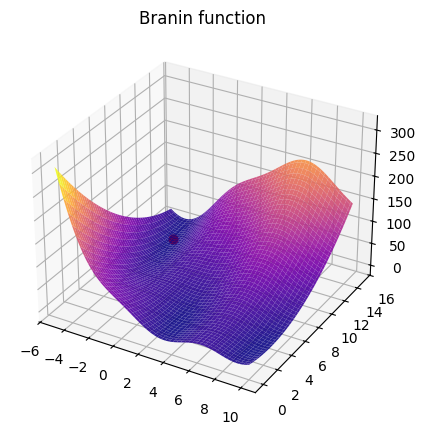

In [77]:
plot_function(
    f_branin,
    bounds_brain[0],
    bounds_brain[1],
    title = "Branin function",
    point = best_solution
)

In [78]:
visualizing_the_process(
    pop_history_brain,
    f_branin,
    bounds_brain[0],
    bounds_brain[1],
    "brain.gif",
)

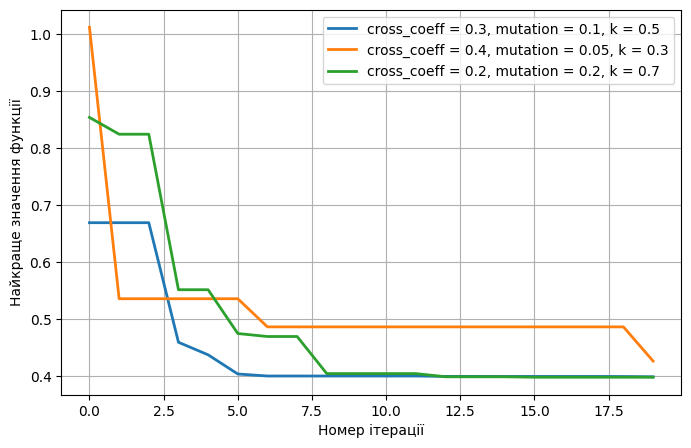

In [13]:
hyperparams_branin = [
    (0.3, 0.1, 0.5),
    (0.4, 0.05, 0.3),
    (0.2, 0.2, 0.7)
]

plot_experiments(
    f_branin,
    hyperparams_branin,
    bounds_brain[0],
    bounds_brain[1]
)

## • Easom function
$$
f(x) = -\cos(x_1)\cos(x_2)\exp\left(- (x_1 - \pi)^2 - (x_2 - \pi)^2 \right)
$$

In [80]:
def f_easom(v):
    x1, x2 = v
    return -np.cos(x1) * np.cos(x2) * np.exp(-((x1 - np.pi)**2 + (x2 - np.pi)**2))

bounds_easom = [(0, 5), (0, 5)]

In [81]:
best_solution, best_value, pop_history_easom, best_history = genetic_algorithm(
    f_easom, 
    bounds_easom[0], 
    bounds_easom[1], 
    cross_coeff = 0.2, 
    mutation_probability = 0.1, 
    k = 0.5 )

print("\nНайкращий знайдений розв'язок:", best_solution)
print("Мінімальне значення функції:", best_value)


Найкращий знайдений розв'язок: [3.141592190839473, 3.1415742463454186]
Мінімальне значення функції: -0.9999999994914388


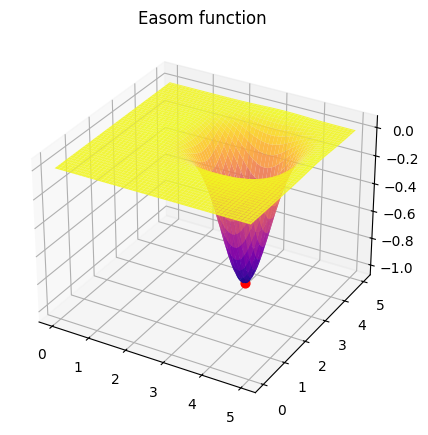

In [82]:
plot_function(
    f_easom,
    bounds_easom[0],
    bounds_easom[1],
    title = "Easom function",
    point = best_solution
)

In [83]:
visualizing_the_process(
    pop_history_easom,
    f_easom,
    bounds_easom[0],
    bounds_easom[1],
    "easom.gif"
)

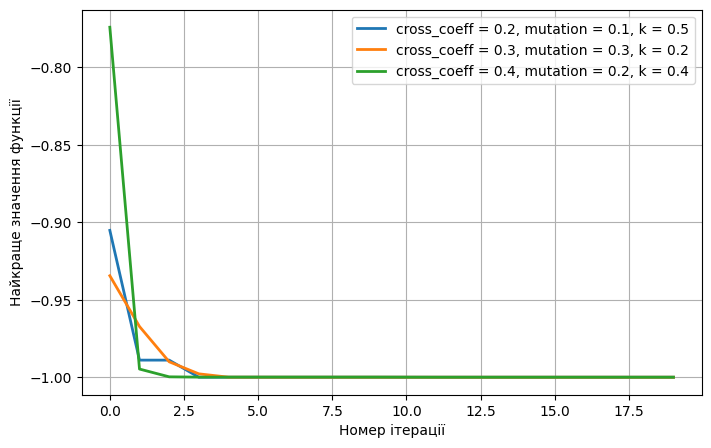

In [84]:
hyperparams_easom = [
    (0.2, 0.1, 0.5),
    (0.3, 0.3, 0.2),
    (0.4, 0.2, 0.4)
]

plot_experiments(
    f_easom,
    hyperparams_easom,
    bounds_easom[0],
    bounds_easom[1]
)

### • The Goldstein-Price function
$$
f(x) =
\left[ 1 + (x_1 + x_2 + 1)^2
\left(19 - 14x_1 + 3x_1^2 - 14x_2 + 6x_1x_2 + 3x_2^2 \right) \right]
$$
$$
\times
\left[ 30 + (2x_1 - 3x_2)^2
\left(18 - 32x_1 + 12x_1^2 + 48x_2 - 36x_1x_2 + 27x_2^2 \right) \right]
$$

In [85]:
def f_goldstein_price(v):
    x1, x2 = v
    
    term1 = 1 + (x1 + x2 + 1)**2 * (
        19 - 14*x1 + 3*x1**2 - 14*x2 + 6*x1*x2 + 3*x2**2
    )
    
    term2 = 30 + (2*x1 - 3*x2)**2 * (
        18 - 32*x1 + 12*x1**2 + 48*x2 - 36*x1*x2 + 27*x2**2
    )
    
    return term1 * term2

bounds_goldstein_price = [(-2, 2), (-2, 2)]

In [86]:
best_solution, best_value, pop_history_goldstein_price, best_history = genetic_algorithm(
    f_goldstein_price, 
    bounds_goldstein_price[0], 
    bounds_goldstein_price[1], 
    cross_coeff = 0.2, 
    mutation_probability = 0.1, 
    k = 0.5 )

print("\nНайкращий знайдений розв'язок:", best_solution)
print("Мінімальне значення функції:", best_value)


Найкращий знайдений розв'язок: [-0.0017195023474327682, -1.001300471452368]
Мінімальне значення функції: 3.0009943415581226


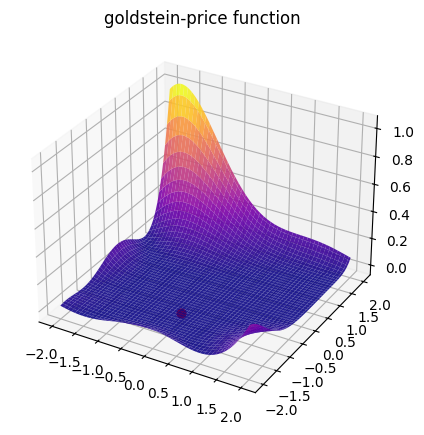

In [87]:
plot_function(
    f_goldstein_price,
    bounds_goldstein_price[0],
    bounds_goldstein_price[1],
    "goldstein-price function",
    best_solution
)

In [88]:
visualizing_the_process(
    pop_history_goldstein_price,
    f_goldstein_price,
    bounds_goldstein_price[0],
    bounds_goldstein_price[1],
    "goldstein_price.gif"
)

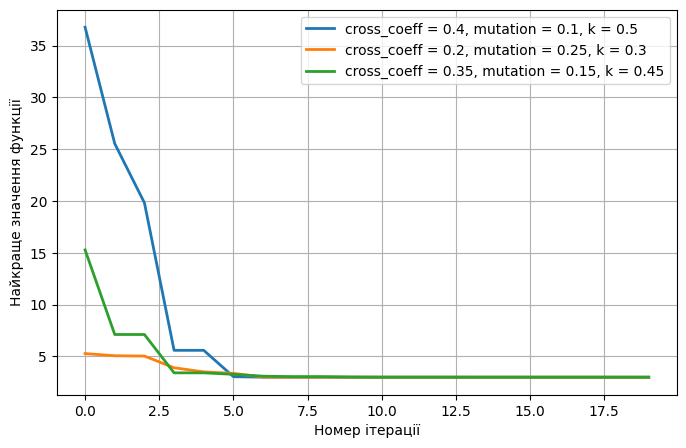

In [89]:
hyperparams_goldstein_price = [
    (0.4, 0.1, 0.5),
    (0.2, 0.25, 0.3),
    (0.35, 0.15, 0.45)
]

plot_experiments(
    f_goldstein_price,
    hyperparams_goldstein_price,
    bounds_goldstein_price[0],
    bounds_goldstein_price[1]
)

### • Six-hump Camel function
$$
f(x) = \left(4 - 2.1x_1^2 + \frac{x_1^4}{3}\right)x_1^2
+ x_1 x_2
+ \left(-4 + 4x_2^2\right)x_2^2
$$

In [ ]:
def f_six_hump_camel(v):
    x1, x2 = v
    
    part1 = (4 - 2.1*x1**2 + (x1**4)/3) * x1**2
    part2 = x1 * x2
    part3 = (-4 + 4*x2**2) * x2**2
    
    return part1 + part2 + part3

bounds_six_hump_camel = [(-3, 3), (-2, 2)]

In [91]:
best_solution, best_value, pop_history_six_hump_camel, best_history = genetic_algorithm(
    f_six_hump_camel, 
    bounds_six_hump_camel[0], 
    bounds_six_hump_camel[1], 
    cross_coeff = 0.2, 
    mutation_probability = 0.1, 
    k = 0.5 )

print("\nНайкращий знайдений розв'язок:", best_solution)
print("Мінімальне значення функції:", best_value)


Найкращий знайдений розв'язок: [0.09114229749091063, -0.711710442848849]
Мінімальне значення функції: -1.0316133152795075


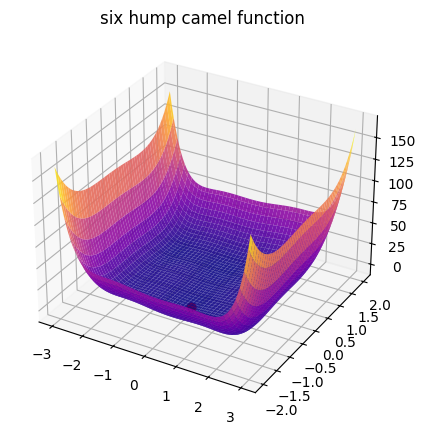

In [92]:
plot_function(
    f_six_hump_camel,
    bounds_six_hump_camel[0],
    bounds_six_hump_camel[1],
    "six hump camel function",
    best_solution
)

In [93]:
visualizing_the_process(
    pop_history_six_hump_camel,
    f_six_hump_camel,
    bounds_six_hump_camel[0],
    bounds_six_hump_camel[1],
    "six_hump_camel.gif"
)

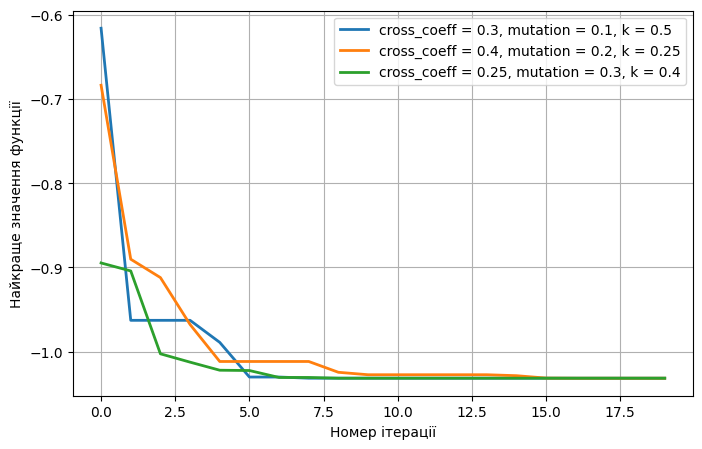

In [95]:
hyperparams_six_hump_camel = [
    (0.3, 0.1, 0.5),
    (0.4, 0.2, 0.25),
    (0.25, 0.3, 0.4)
]

plot_experiments(
    f_six_hump_camel,
    hyperparams_six_hump_camel,
    bounds_six_hump_camel[0],
    bounds_six_hump_camel[1]
)